In [1]:
!pip -q install --upgrade numpy==1.26.4 scipy==1.11.4
!pip -q install mne==1.3.0 tqdm scikit-learn matplotlib



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
from pathlib import Path
import os, json, time, random, warnings
from typing import List, Tuple, Dict, Optional, Any

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.metrics import roc_auc_score, confusion_matrix

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/workspace/NeuroXAI")
DATA_CACHE = PROJECT_ROOT / "data_cache"
OUT_DIR = PROJECT_ROOT / "outputs"
CKPT_DIR = OUT_DIR / "checkpoints"
SPLITS_DIR = OUT_DIR / "splits"
FIG_DIR = OUT_DIR / "figures"
LOG_DIR = OUT_DIR / "logs"

for d in [DATA_CACHE, OUT_DIR, CKPT_DIR, SPLITS_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

MAX_EPOCHS = 240
EARLY_STOP_PATIENCE = 15
BATCH_SIZE = 64

LR = 2e-3
WEIGHT_DECAY = 1e-4

AMP = True
GRAD_CLIP = 1.0

USE_FOCAL_LOSS = True
FOCAL_ALPHA = 0.4
FOCAL_GAMMA = 2.0

T0 = 25
T_MULT = 2

THR_MIN = 0.05
THR_MAX = 0.95
THR_STEPS = 91

NUM_WORKERS = 4 if DEVICE == "cuda" else 0
PIN_MEMORY = (DEVICE == "cuda")

MODEL_NAME = "mst_gat"      # choose: "cnn", "cnn_lstm", "mst_gat"
RUN_MODE = "dev"            # choose: "dev" or "loso"
SPLIT_MODE = "realistic"    # choose: "benchmark" or "realistic" (used only in dev mode)
LOSO_MAX_FOLDS = None       # set 5 or 10 for partial LOSO


In [4]:
with open(DATA_CACHE / "patient_meta.json", "r") as f:
    patient_meta = json.load(f)

if RUN_MODE == "dev":
    if SPLIT_MODE == "benchmark":
        split_file = SPLITS_DIR / "patient_splits_benchmark.json"
    elif SPLIT_MODE == "realistic":
        split_file = SPLITS_DIR / "patient_splits_dev.json"
    else:
        raise ValueError(f"Unknown SPLIT_MODE: {SPLIT_MODE}")

    with open(split_file, "r") as f:
        split_obj = json.load(f)

    train_ids = split_obj["train_ids"]
    val_ids = split_obj["val_ids"]
    test_ids = split_obj["test_ids"]

    print("RUN_MODE:", RUN_MODE)
    print("SPLIT_MODE:", SPLIT_MODE)
    print("TRAIN:", train_ids)
    print("VAL  :", val_ids)
    print("TEST :", test_ids)

elif RUN_MODE == "loso":
    with open(SPLITS_DIR / "patient_splits_loso.json", "r") as f:
        loso_obj = json.load(f)

    loso_folds = loso_obj["folds"]
    if LOSO_MAX_FOLDS is not None:
        loso_folds = loso_folds[:LOSO_MAX_FOLDS]

    print("RUN_MODE:", RUN_MODE)
    print("Total LOSO folds to run:", len(loso_folds))


RUN_MODE: dev
SPLIT_MODE: realistic
TRAIN: [2, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 23, 24, 25, 27, 28, 30, 31, 33, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 66, 69, 71, 72, 73, 74, 75, 76, 77, 79]
VAL  : [1, 19, 29, 34, 35, 39, 49, 67]
TEST : [3, 4, 5, 6, 10, 15, 20, 21, 22, 26, 32, 64, 65, 68, 70, 78]


In [5]:
BIPOLAR_PAIRS = [
    ("Fp2", "F4"), ("F4", "C4"), ("C4", "P4"), ("P4", "O2"),
    ("Fp1", "F3"), ("F3", "C3"), ("C3", "P3"), ("P3", "O1"),
    ("Fp2", "F8"), ("F8", "T4"), ("T4", "T6"), ("T6", "O2"),
    ("Fp1", "F7"), ("F7", "T3"), ("T3", "T5"), ("T5", "O1"),
    ("Fz", "Cz"), ("Cz", "Pz"),
]
BIPOLAR_NAMES = [f"{a}-{b}" for a, b in BIPOLAR_PAIRS]


In [6]:
class WindowDatasetNPY(Dataset):
    def __init__(self, patient_ids: List[int], npy_dir: Path, meta: Dict[str, Any]):
        self.npy_dir = npy_dir
        self.patient_ids = list(patient_ids)
        self.meta = meta
        self.items = []

        for pid in self.patient_ids:
            n = int(meta[str(pid)]["total_windows"])
            self.items.extend([(pid, wi) for wi in range(n)])

        self._cache_pid = None
        self._X = None
        self._y = None

        print(f"[DatasetNPY] windows={len(self.items)} patients={len(self.patient_ids)}")

    def __len__(self):
        return len(self.items)

    def _load_patient(self, pid: int):
        self._X = np.load(self.npy_dir / f"patient_{pid:02d}_X.npy", mmap_mode="r")
        self._y = np.load(self.npy_dir / f"patient_{pid:02d}_y.npy", mmap_mode="r")
        self._cache_pid = pid

    def __getitem__(self, idx: int):
        pid, wi = self.items[idx]
        if self._cache_pid != pid:
            self._load_patient(pid)

        x = np.array(self._X[wi], dtype=np.float32)
        y = float(self._y[wi])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32), pid

class FastBalancedBatchSampler(Sampler[List[int]]):
    def __init__(self, patient_ids: List[int], npy_dir: Path, meta: Dict[str, Any], batch_size: int, seed: int = 42):
        assert batch_size % 2 == 0, "batch_size must be even for 50/50 class balancing"

        self.batch_size = batch_size
        self.half = batch_size // 2
        self.rng = np.random.default_rng(seed)

        pos, neg = [], []
        idx_offset = 0

        for pid in patient_ids:
            y = np.load(npy_dir / f"patient_{pid:02d}_y.npy", mmap_mode="r")
            n = len(y)

            pos.extend((np.where(y == 1)[0] + idx_offset).tolist())
            neg.extend((np.where(y == 0)[0] + idx_offset).tolist())

            idx_offset += n

        if len(pos) == 0 or len(neg) == 0:
            raise RuntimeError(f"Sampler missing class: pos={len(pos)} neg={len(neg)}")

        self.pos = np.array(pos, dtype=np.int64)
        self.neg = np.array(neg, dtype=np.int64)
        self.num_batches = max(1, idx_offset // batch_size)

        print(f"[Sampler] pos={len(self.pos)} neg={len(self.neg)} batches/epoch={self.num_batches}")

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        for _ in range(self.num_batches):
            p = self.rng.choice(self.pos, size=self.half, replace=True)
            n = self.rng.choice(self.neg, size=self.half, replace=True)
            batch = np.concatenate([p, n])
            self.rng.shuffle(batch)
            yield batch.tolist()

def build_dataloaders(train_ids, val_ids, test_ids, npy_dir, meta, batch_size, num_workers=0, pin_memory=False, seed=42):
    train_ds = WindowDatasetNPY(train_ids, npy_dir, meta)
    val_ds   = WindowDatasetNPY(val_ids, npy_dir, meta)
    test_ds  = WindowDatasetNPY(test_ids, npy_dir, meta)

    train_loader = DataLoader(
        train_ds,
        batch_sampler=FastBalancedBatchSampler(train_ids, npy_dir, meta, batch_size=batch_size, seed=seed),
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


In [7]:
edges = set()
for i, (a1, b1) in enumerate(BIPOLAR_PAIRS):
    for j, (a2, b2) in enumerate(BIPOLAR_PAIRS):
        if i != j and len({a1, b1}.intersection({a2, b2})) > 0:
            edges.add((i, j))
            edges.add((j, i))

idx_fzcz = BIPOLAR_NAMES.index("Fz-Cz")
idx_czpz = BIPOLAR_NAMES.index("Cz-Pz")
for nm in ["F4-C4", "F3-C3", "C4-P4", "C3-P3"]:
    k = BIPOLAR_NAMES.index(nm)
    edges.add((idx_fzcz, k))
    edges.add((k, idx_fzcz))
    edges.add((idx_czpz, k))
    edges.add((k, idx_czpz))

edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
print("Number of nodes:", len(BIPOLAR_NAMES))
print("Number of edges:", edge_index.shape[1])
print("edge_index shape:", tuple(edge_index.shape))


Number of nodes: 18
Number of edges: 50
edge_index shape: (2, 50)


In [8]:
class TemporalBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernels: List[int], dropout: float):
        super().__init__()
        layers = []
        cur = in_ch
        for k in kernels:
            layers += [
                nn.Conv1d(cur, out_ch, k, padding=k // 2, bias=False),
                nn.BatchNorm1d(out_ch),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            cur = out_ch
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class CNNBaseline(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.fe = nn.Sequential(
            nn.Conv1d(18, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=11, padding=5, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(25),
        )
        self.cls = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 25, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor, edge_index: Optional[torch.Tensor] = None) -> torch.Tensor:
        z = self.fe(x)
        return self.cls(z).squeeze(-1)

class CNNLSTMBaseline(nn.Module):
    def __init__(self, hidden=128, dropout=0.2):
        super().__init__()
        self.fe = nn.Sequential(
            nn.Conv1d(18, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=11, padding=5, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(50),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden, num_layers=1, batch_first=True, bidirectional=True)
        self.cls = nn.Sequential(
            nn.Linear(hidden * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor, edge_index: Optional[torch.Tensor] = None) -> torch.Tensor:
        z = self.fe(x)
        z = z.transpose(1, 2)
        out, _ = self.lstm(z)
        h = out.mean(dim=1)
        return self.cls(h).squeeze(-1)

class GATLayer(nn.Module):
    def __init__(self, fin: int, fout: int, heads: int, dropout: float = 0.1, negative_slope: float = 0.2):
        super().__init__()
        self.fin = fin
        self.fout = fout
        self.heads = heads
        self.dropout = dropout
        self.negative_slope = negative_slope

        self.W = nn.Linear(fin, heads * fout, bias=False)
        self.a_src = nn.Parameter(torch.empty(heads, fout))
        self.a_dst = nn.Parameter(torch.empty(heads, fout))

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)
        self.last_alpha = None

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        B, N, _ = x.shape
        E = edge_index.shape[1]

        src = edge_index[0].to(x.device)
        dst = edge_index[1].to(x.device)

        h = self.W(x).view(B, N, self.heads, self.fout)
        h_src = h[:, src, :, :]
        h_dst = h[:, dst, :, :]

        e = ((h_src * self.a_src[None, None, :, :]).sum(-1) + (h_dst * self.a_dst[None, None, :, :]).sum(-1))
        e = F.leaky_relu(e, negative_slope=self.negative_slope)

        alpha = torch.zeros_like(e)
        for n in range(N):
            mask = (dst == n)
            if mask.sum() == 0:
                continue
            logits = e[:, mask, :]
            logits = logits - logits.max(dim=1, keepdim=True).values
            attn = torch.exp(logits)
            attn = attn / (attn.sum(dim=1, keepdim=True) + 1e-9)
            alpha[:, mask, :] = attn

        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        self.last_alpha = alpha.permute(0, 2, 1).detach()

        out = torch.zeros(B, N, self.heads, self.fout, device=x.device, dtype=x.dtype)
        for ei in range(E):
            out[:, dst[ei], :, :] += alpha[:, ei, :].unsqueeze(-1) * h_src[:, ei, :, :]
        return out.reshape(B, N, self.heads * self.fout)

class MSTGAT(nn.Module):
    def __init__(self, embed_dim: int, heads: int, dropout: float):
        super().__init__()
        self.embed_dim = embed_dim
        self.heads = heads

        self.short = TemporalBlock(1, 32, [3, 5, 7], 0.2)
        self.medium = TemporalBlock(1, 32, [7, 15, 31], 0.2)
        self.long = nn.Sequential(
            nn.Conv1d(1, 32, 63, padding=31, bias=False),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.AvgPool1d(4, 4),
            nn.Conv1d(32, 32, 31, padding=15, bias=False),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(25)
        )

        self.node_proj = nn.Linear(32 * 3, embed_dim)
        self.node_norm = nn.LayerNorm(embed_dim)
        self.node_dropout = nn.Dropout(dropout)

        self.gat1 = GATLayer(embed_dim, embed_dim // heads, heads, dropout=0.1)
        self.gat2 = GATLayer(embed_dim, embed_dim // heads, heads, dropout=0.1)
        self.gat_norm = nn.LayerNorm(embed_dim)

        self.temporal_tok_proj = nn.Linear(32, embed_dim)
        self.temporal_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=4, dropout=0.1, batch_first=True)
        self.temporal_norm1 = nn.LayerNorm(embed_dim)
        self.temporal_norm2 = nn.LayerNorm(embed_dim)
        self.temporal_ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim * 2, embed_dim),
            nn.Dropout(0.1),
        )
        self.last_temporal_attn = None

        fused_dim = (32 + 32 + 32) + embed_dim + embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        B, N, T = x.shape
        xn = x.reshape(B * N, 1, T)

        short_f = self.short(xn)
        med_f   = self.medium(xn)
        long_f  = self.long(xn)

        short_vec = F.adaptive_avg_pool1d(short_f, 1).squeeze(-1)
        med_vec   = F.adaptive_avg_pool1d(med_f, 1).squeeze(-1)
        long_vec  = F.adaptive_avg_pool1d(long_f, 1).squeeze(-1)

        node_feat = torch.cat([short_vec, med_vec, long_vec], dim=1)
        node_emb = self.node_proj(node_feat).view(B, N, self.embed_dim)
        node_emb = self.node_dropout(self.node_norm(node_emb))

        g = F.gelu(self.gat1(node_emb, edge_index))
        g = self.gat2(g, edge_index)
        g = self.gat_norm(g + node_emb)
        spatial_summary = g.mean(dim=1)

        med_f_ = med_f.view(B, N, 32, T).mean(dim=1)
        L = 50
        tokens = F.adaptive_avg_pool1d(med_f_, L).transpose(1, 2)
        tok = F.gelu(self.temporal_tok_proj(tokens))

        attn_out, attn_w = self.temporal_attn(tok, tok, tok, need_weights=True, average_attn_weights=False)
        self.last_temporal_attn = attn_w.detach()

        tok2 = self.temporal_norm1(tok + attn_out)
        tok3 = self.temporal_norm2(tok2 + self.temporal_ff(tok2))
        temporal_summary = tok3.mean(dim=1)

        short_global = short_vec.view(B, N, 32).mean(dim=1)
        med_global   = med_vec.view(B, N, 32).mean(dim=1)
        long_global  = long_vec.view(B, N, 32).mean(dim=1)

        fused = torch.cat([short_global, med_global, long_global, spatial_summary, temporal_summary], dim=1)
        logits = self.classifier(fused).squeeze(-1)
        return logits


In [9]:
GAT_HEADS = 4
EMBED_DIM = GAT_HEADS * 32
MODEL_DROPOUT = 0.2

def build_model(model_name: str):
    if model_name == "cnn":
        return CNNBaseline(dropout=MODEL_DROPOUT).to(DEVICE)
    elif model_name == "cnn_lstm":
        return CNNLSTMBaseline(dropout=MODEL_DROPOUT).to(DEVICE)
    elif model_name == "mst_gat":
        return MSTGAT(embed_dim=EMBED_DIM, heads=GAT_HEADS, dropout=MODEL_DROPOUT).to(DEVICE)
    else:
        raise ValueError(f"Unknown MODEL_NAME: {model_name}")


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha_pos: float = 0.4, gamma: float = 2.0):
        super().__init__()
        self.alpha_pos = alpha_pos
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = targets * p + (1.0 - targets) * (1.0 - p)
        alpha_t = targets * self.alpha_pos + (1.0 - targets) * (1.0 - self.alpha_pos)
        focal_weight = alpha_t * (1.0 - pt).pow(self.gamma)
        return (focal_weight * bce).mean()

def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, thr: float) -> Dict[str, float]:
    y_pred = (y_prob >= thr).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    beta2 = 4.0
    f2 = (1.0 + beta2) * prec * sens / (beta2 * prec + sens + 1e-9)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")

    return {"AUC": auc, "Sensitivity": sens, "Specificity": spec, "Precision": prec, "F2": f2, "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)}

def tune_threshold(y_true: np.ndarray, y_prob: np.ndarray):
    best_thr = 0.5
    best_metrics = None
    for thr in np.linspace(THR_MIN, THR_MAX, THR_STEPS):
        m = compute_metrics(y_true, y_prob, float(thr))
        if best_metrics is None or m["F2"] > best_metrics["F2"]:
            best_thr = float(thr)
            best_metrics = m
    return best_thr, best_metrics

def save_ckpt(path: Path, model: nn.Module, optim: torch.optim.Optimizer, epoch: int, best_auc: float, scheduler=None, best_thr: float = 0.5):
    ckpt = {"epoch": epoch, "best_auc": best_auc, "best_thr": best_thr, "model": model.state_dict(), "optimizer": optim.state_dict()}
    if scheduler is not None:
        ckpt["scheduler"] = scheduler.state_dict()
    torch.save(ckpt, str(path))

def load_ckpt(path: Path, model: nn.Module, optim: Optional[torch.optim.Optimizer] = None, scheduler=None):
    ck = torch.load(str(path), map_location="cpu")
    model.load_state_dict(ck["model"])
    if optim is not None and "optimizer" in ck:
        optim.load_state_dict(ck["optimizer"])
    if scheduler is not None and "scheduler" in ck:
        scheduler.load_state_dict(ck["scheduler"])
    return ck

def run_eval(model: nn.Module, loader: DataLoader, loss_fn, edge_index_dev: Optional[torch.Tensor], model_name: str):
    model.eval()
    all_y, all_p = [], []
    total_loss, nb = 0.0, 0

    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            logits = model(x, edge_index_dev) if model_name == "mst_gat" else model(x, None)
            loss = loss_fn(logits, y)
            total_loss += float(loss.item())
            nb += 1
            all_p.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_y.append(y.detach().cpu().numpy())

    return total_loss / max(1, nb), np.concatenate(all_y).astype(np.int64), np.concatenate(all_p).astype(np.float32)


In [11]:
def train_one_run(train_ids, val_ids, test_ids, model_name, run_tag):
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = build_dataloaders(
        train_ids=train_ids,
        val_ids=val_ids,
        test_ids=test_ids,
        npy_dir=DATA_CACHE,
        meta=patient_meta,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        seed=42,
    )

    model = build_model(model_name)
    loss_fn = FocalLoss(alpha_pos=FOCAL_ALPHA, gamma=FOCAL_GAMMA) if USE_FOCAL_LOSS else nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T0, T_mult=T_MULT)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda" and AMP))
    edge_index_dev = edge_index.to(DEVICE)

    best_auc = -1.0
    best_epoch = -1
    best_thr = 0.5
    pat = 0
    ckpt_path = CKPT_DIR / f"{run_tag}_{model_name}_best.pt"

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for x, y, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda" and AMP)):
                logits = model(x, edge_index_dev) if model_name == "mst_gat" else model(x, None)
                loss = loss_fn(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

        scheduler.step(epoch + 0.0)

        _, yv_true, yv_prob = run_eval(
            model,
            val_loader,
            loss_fn,
            edge_index_dev if model_name == "mst_gat" else None,
            model_name
        )
        thr, val_metrics = tune_threshold(yv_true, yv_prob)

        if not np.isnan(val_metrics["AUC"]) and val_metrics["AUC"] > best_auc:
            best_auc = float(val_metrics["AUC"])
            best_epoch = epoch
            best_thr = thr
            pat = 0
            save_ckpt(ckpt_path, model, optimizer, epoch, best_auc, scheduler=scheduler, best_thr=best_thr)
        else:
            pat += 1

        if pat >= EARLY_STOP_PATIENCE:
            break

    ck = load_ckpt(ckpt_path, model, optim=None, scheduler=None)

    val_loss, yv_true, yv_prob = run_eval(
        model,
        val_loader,
        loss_fn,
        edge_index_dev if model_name == "mst_gat" else None,
        model_name
    )
    thr, val_metrics = tune_threshold(yv_true, yv_prob)

    test_loss, yt_true, yt_prob = run_eval(
        model,
        test_loader,
        loss_fn,
        edge_index_dev if model_name == "mst_gat" else None,
        model_name
    )
    test_metrics = compute_metrics(yt_true, yt_prob, thr)
    yt_pred = (yt_prob >= thr).astype(np.int64)

    result = {
        "run_tag": run_tag,
        "model_name": model_name,
        "best_epoch": int(ck.get("epoch")),
        "best_val_auc": float(ck.get("best_auc")),
        "threshold": float(thr),
        "test_auc": float(test_metrics["AUC"]),
        "test_sensitivity": float(test_metrics["Sensitivity"]),
        "test_specificity": float(test_metrics["Specificity"]),
        "test_precision": float(test_metrics["Precision"]),
        "test_f2": float(test_metrics["F2"]),
        "tp": int(test_metrics["TP"]),
        "fp": int(test_metrics["FP"]),
        "tn": int(test_metrics["TN"]),
        "fn": int(test_metrics["FN"]),
        "yt_true": yt_true.tolist(),
        "yt_prob": yt_prob.tolist(),
        "yt_pred": yt_pred.tolist(),
        "train_ids": list(map(int, train_ids)),
        "val_ids": list(map(int, val_ids)),
        "test_ids": list(map(int, test_ids)),
        "ckpt_path": str(ckpt_path),
    }
    return result

In [12]:
if RUN_MODE == "dev":
    result = train_one_run(
        train_ids=train_ids,
        val_ids=val_ids,
        test_ids=test_ids,
        model_name=MODEL_NAME,
        run_tag=f"{SPLIT_MODE}"
    )
    print(result)


[DatasetNPY] windows=30785 patients=55
[DatasetNPY] windows=6062 patients=8
[DatasetNPY] windows=8589 patients=16
[Sampler] pos=6675 neg=24110 batches/epoch=481
{'run_tag': 'realistic', 'model_name': 'mst_gat', 'best_epoch': 21, 'best_val_auc': 0.9297132192701812, 'threshold': 0.20999999999999996, 'test_auc': 0.8266463946402014, 'test_sensitivity': 0.7250608272502554, 'test_specificity': 0.7823691460053899, 'test_precision': 0.5116758241756485, 'test_f2': 0.6692418251265573, 'tp': 1490, 'fp': 1422, 'tn': 5112, 'fn': 565, 'yt_true': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [13]:
# Run this cell when you want the full dev-set comparison table for all 3 models.
if RUN_MODE == "dev":
    comparison_results = []
    for model_name in ["cnn", "cnn_lstm", "mst_gat"]:
        print(f"\n=== Running {model_name} on {SPLIT_MODE} split ===")
        res = train_one_run(
            train_ids=train_ids,
            val_ids=val_ids,
            test_ids=test_ids,
            model_name=model_name,
            run_tag=f"{SPLIT_MODE}"
        )
        comparison_results.append(res)

    comp_path = LOG_DIR / f"comparison_{SPLIT_MODE}.json"
    with open(comp_path, "w") as f:
        json.dump(comparison_results, f, indent=2)

    print("\n=== COMPARISON TABLE ===")
    for r in comparison_results:
        print(
            r["model_name"],
            "| AUC:", round(r["test_auc"], 4),
            "| Sens:", round(r["test_sensitivity"], 4),
            "| Spec:", round(r["test_specificity"], 4),
            "| Prec:", round(r["test_precision"], 4),
            "| F2:", round(r["test_f2"], 4),
            "| Thr:", round(r["threshold"], 4),
        )
    print("Saved:", comp_path)



=== Running cnn on realistic split ===
[DatasetNPY] windows=30785 patients=55
[DatasetNPY] windows=6062 patients=8
[DatasetNPY] windows=8589 patients=16
[Sampler] pos=6675 neg=24110 batches/epoch=481

=== Running cnn_lstm on realistic split ===
[DatasetNPY] windows=30785 patients=55
[DatasetNPY] windows=6062 patients=8
[DatasetNPY] windows=8589 patients=16
[Sampler] pos=6675 neg=24110 batches/epoch=481

=== Running mst_gat on realistic split ===
[DatasetNPY] windows=30785 patients=55
[DatasetNPY] windows=6062 patients=8
[DatasetNPY] windows=8589 patients=16
[Sampler] pos=6675 neg=24110 batches/epoch=481

=== COMPARISON TABLE ===
cnn | AUC: 0.7575 | Sens: 0.9723 | Spec: 0.1321 | Prec: 0.2605 | F2: 0.6287 | Thr: 0.16
cnn_lstm | AUC: 0.7958 | Sens: 0.9075 | Spec: 0.3534 | Prec: 0.3062 | F2: 0.6516 | Thr: 0.24
mst_gat | AUC: 0.8596 | Sens: 0.7698 | Spec: 0.756 | Prec: 0.4981 | F2: 0.6941 | Thr: 0.21
Saved: /workspace/NeuroXAI/outputs/logs/comparison_realistic.json


In [15]:
!pip install pandas scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 34.8 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [16]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc
from IPython.display import display

def model_display_name(name):
    mapping = {
        "cnn": "CNN",
        "cnn_lstm": "CNN-LSTM",
        "mst_gat": "MST-GAT",
    }
    return mapping.get(name, name)

def plot_confusion_matrix_from_result(result, save_name=None):
    y_true = np.array(result["yt_true"])
    y_pred = np.array(result["yt_pred"])

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Seizure", "Seizure"]
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix of {model_display_name(result['model_name'])}")
    plt.tight_layout()

    if save_name is None:
        save_name = f"confusion_matrix_{result['model_name']}.png"
    out_path = FIG_DIR / save_name
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return cm, out_path

def plot_roc_comparison(comparison_results, save_name="roc_comparison_all_models.png"):
    plt.figure(figsize=(7, 6))

    for result in comparison_results:
        y_true = np.array(result["yt_true"])
        y_prob = np.array(result["yt_prob"])

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{model_display_name(result['model_name'])} (AUC = {roc_auc:.4f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison of CNN, CNN-LSTM, and MST-GAT")
    plt.legend(loc="lower right")
    plt.tight_layout()

    out_path = FIG_DIR / save_name
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return out_path

def export_summary_tables(comparison_results, prefix="comparison_dev"):
    rows = []
    for r in comparison_results:
        rows.append({
            "Model": model_display_name(r["model_name"]),
            "AUC": r["test_auc"],
            "Sensitivity": r["test_sensitivity"],
            "Specificity": r["test_specificity"],
            "Precision": r["test_precision"],
            "F2": r["test_f2"],
            "Threshold": r["threshold"],
            "TP": r["tp"],
            "FP": r["fp"],
            "TN": r["tn"],
            "FN": r["fn"],
            "Best Epoch": r["best_epoch"],
            "Best Val AUC": r["best_val_auc"],
        })

    df = pd.DataFrame(rows)
    csv_path = LOG_DIR / f"{prefix}.csv"
    df.to_csv(csv_path, index=False)
    print("Saved CSV:", csv_path)
    display(df)
    return df, csv_path

Saved CSV: /workspace/NeuroXAI/outputs/logs/comparison_realistic.csv


,Model,AUC,Sensitivity,Specificity,Precision,F2,Threshold,TP,FP,TN,FN,Best Epoch,Best Val AUC
0,CNN,0.757532,0.972263,0.132078,0.260529,0.628737,0.16,1998,5671,863,57,5,0.808091
1,CNN-LSTM,0.795751,0.907543,0.353382,0.306240,0.651642,0.24,1865,4225,2309,190,7,0.829894
2,MST-GAT,0.859577,0.769830,0.756045,0.498111,0.694103,0.21,1582,1594,4940,473,21,0.920350


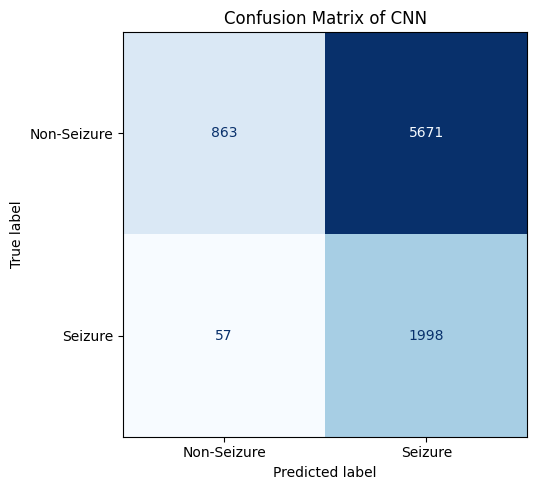

Saved confusion matrix for cnn: /workspace/NeuroXAI/outputs/figures/confusion_matrix_cnn.png


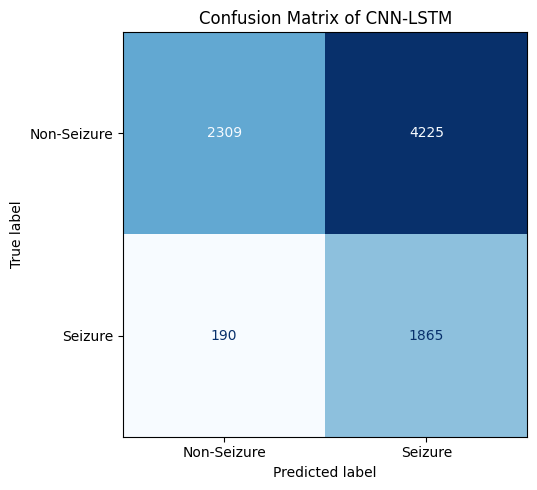

Saved confusion matrix for cnn_lstm: /workspace/NeuroXAI/outputs/figures/confusion_matrix_cnn_lstm.png


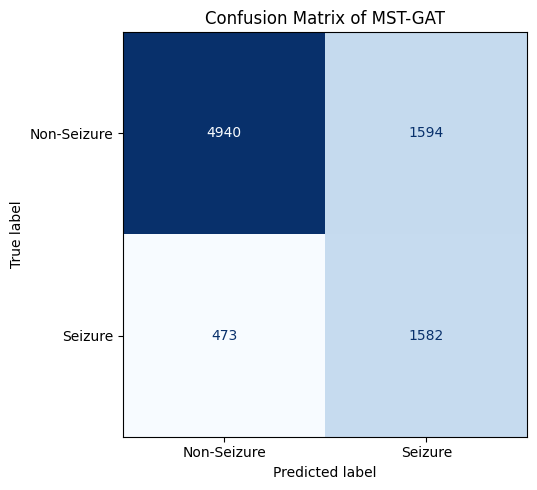

Saved confusion matrix for mst_gat: /workspace/NeuroXAI/outputs/figures/confusion_matrix_mst_gat.png


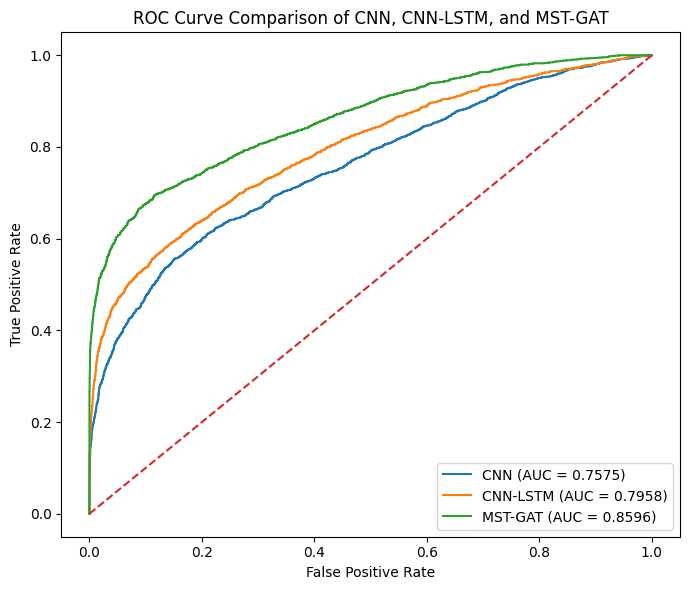

Saved ROC figure: /workspace/NeuroXAI/outputs/figures/roc_comparison_all_models.png


In [17]:
# Run this after the comparison cell finishes and comparison_results is available.

df_summary, csv_path = export_summary_tables(comparison_results, prefix=f"comparison_{SPLIT_MODE}")

for r in comparison_results:
    cm, cm_path = plot_confusion_matrix_from_result(r)
    print(f"Saved confusion matrix for {r['model_name']}:", cm_path)

roc_path = plot_roc_comparison(comparison_results)
print("Saved ROC figure:", roc_path)

In [18]:
# Run this cell for LOSO evaluation, usually with MODEL_NAME='mst_gat'.
if RUN_MODE == "loso":
    loso_results = []
    for i, fold in enumerate(loso_folds, start=1):
        test_id = fold["test_id"]
        print(f"\n=== LOSO FOLD {i}/{len(loso_folds)} | test_id={test_id} ===")
        res = train_one_run(
            train_ids=fold["train_ids"],
            val_ids=fold["val_ids"],
            test_ids=[test_id],
            model_name=MODEL_NAME,
            run_tag=f"loso_fold_{test_id:02d}"
        )
        res["test_id"] = int(test_id)
        loso_results.append(res)

    loso_path = LOG_DIR / f"loso_results_{MODEL_NAME}.json"
    with open(loso_path, "w") as f:
        json.dump(loso_results, f, indent=2)
    print("Saved:", loso_path)


In [19]:
def summarize_loso_results(path):
    with open(path, "r") as f:
        arr = json.load(f)

    keys = ["test_auc", "test_sensitivity", "test_specificity", "test_precision", "test_f2"]
    summary = {}
    for k in keys:
        vals = np.array([x[k] for x in arr], dtype=float)
        summary[k] = {"mean": float(vals.mean()), "std": float(vals.std())}
    return summary

# Example:
# summary = summarize_loso_results(LOG_DIR / "loso_results_mst_gat.json")
# print(summary)


In [22]:
# Optional explanation cell for CNN, CNN-LSTM, or MST-GAT after a dev run.
# Set RUN_MODE='dev' first. For MST-GAT this also saves graph-attention and temporal-attention maps.
def explain_one_batch(model, test_loader, threshold, model_name, save_prefix="final_explain"):
    edge_dev = edge_index.to(DEVICE)

    # CNN-LSTM saliency needs training mode for cuDNN RNN backward
    # but we are not updating weights, only computing gradients wrt input
    if model_name == "cnn_lstm":
        model.train()
    else:
        model.eval()

    x, y, pid = next(iter(test_loader))
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    x.requires_grad_(True)

    if model_name == "mst_gat":
        logits = model(x, edge_dev)
    else:
        logits = model(x, None)

    prob = torch.sigmoid(logits)

    tp_candidates = torch.where((y > 0.5) & (prob >= threshold))[0]
    if len(tp_candidates) > 0:
        best_local = torch.argmax(prob[tp_candidates]).item()
        idx = int(tp_candidates[best_local].item())
    else:
        seizure_candidates = torch.where(y > 0.5)[0]
        if len(seizure_candidates) > 0:
            best_local = torch.argmax(prob[seizure_candidates]).item()
            idx = int(seizure_candidates[best_local].item())
        else:
            idx = int(torch.argmax(prob).item())

    score = logits[idx]
    pred_prob = float(prob[idx].item())
    true_label = int(y[idx].item())
    pred_label = int(pred_prob >= threshold)
    patient_id = int(pid[idx])
    
    model.zero_grad(set_to_none=True)
    
    if model_name == "cnn_lstm":
        with torch.backends.cudnn.flags(enabled=False):
            score.backward()
    else:
        score.backward()

    outputs = {}

    # 1) Saliency map for all models
    sal = x.grad[idx].detach().cpu().numpy()
    sal = np.abs(sal)
    sal = sal / (sal.max() + 1e-8)

    plt.figure(figsize=(12, 4))
    plt.imshow(sal, aspect="auto")
    plt.colorbar()
    plt.yticks(range(len(BIPOLAR_NAMES)), BIPOLAR_NAMES, fontsize=7)
    plt.xlabel("Time samples")
    plt.ylabel("Bipolar EEG channels")
    plt.title(f"{model_display_name(model_name)} Gradient Saliency | Patient {patient_id} | True={true_label} | PredProb={pred_prob:.3f}")
    sal_path = FIG_DIR / f"{save_prefix}_{model_name}_saliency.png"
    plt.tight_layout()
    plt.savefig(sal_path, dpi=300, bbox_inches="tight")
    plt.show()
    outputs["saliency_fig"] = str(sal_path)

    # 2) MST-GAT graph attention
    if model_name == "mst_gat":
        if getattr(model.gat2, "last_alpha", None) is not None:
            alpha = model.gat2.last_alpha[idx].detach().cpu().numpy()  # [heads, edges]
            alpha_mean = alpha.mean(axis=0)

            src = edge_index[0].cpu().numpy()
            dst = edge_index[1].cpu().numpy()
            N = len(BIPOLAR_NAMES)
            adj = np.zeros((N, N), dtype=np.float32)

            for e in range(len(alpha_mean)):
                adj[src[e], dst[e]] = alpha_mean[e]

            plt.figure(figsize=(8, 7))
            plt.imshow(adj, aspect="auto")
            plt.colorbar()
            plt.xticks(range(N), BIPOLAR_NAMES, rotation=90, fontsize=6)
            plt.yticks(range(N), BIPOLAR_NAMES, fontsize=6)
            plt.xlabel("Destination channel")
            plt.ylabel("Source channel")
            plt.title(f"MST-GAT Graph Attention Map | Patient {patient_id}")
            gat_path = FIG_DIR / f"{save_prefix}_{model_name}_graph_attention.png"
            plt.tight_layout()
            plt.savefig(gat_path, dpi=300, bbox_inches="tight")
            plt.show()
            outputs["graph_attention_fig"] = str(gat_path)

        # 3) MST-GAT temporal attention
        if getattr(model, "last_temporal_attn", None) is not None:
            tattn = model.last_temporal_attn[idx].detach().cpu().numpy()  # [heads, L, L]
            tattn_mean = tattn.mean(axis=0)

            plt.figure(figsize=(7, 6))
            plt.imshow(tattn_mean, aspect="auto")
            plt.colorbar()
            plt.xlabel("Key token position")
            plt.ylabel("Query token position")
            plt.title(f"MST-GAT Temporal Attention Map | Patient {patient_id}")
            temp_path = FIG_DIR / f"{save_prefix}_{model_name}_temporal_attention.png"
            plt.tight_layout()
            plt.savefig(temp_path, dpi=300, bbox_inches="tight")
            plt.show()
            outputs["temporal_attention_fig"] = str(temp_path)

    outputs.update({
        "patient_id": patient_id,
        "true_label": true_label,
        "pred_label": pred_label,
        "pred_prob": pred_prob,
    })

    return outputs

[DatasetNPY] windows=30785 patients=55
[DatasetNPY] windows=6062 patients=8
[DatasetNPY] windows=8589 patients=16
[Sampler] pos=6675 neg=24110 batches/epoch=481


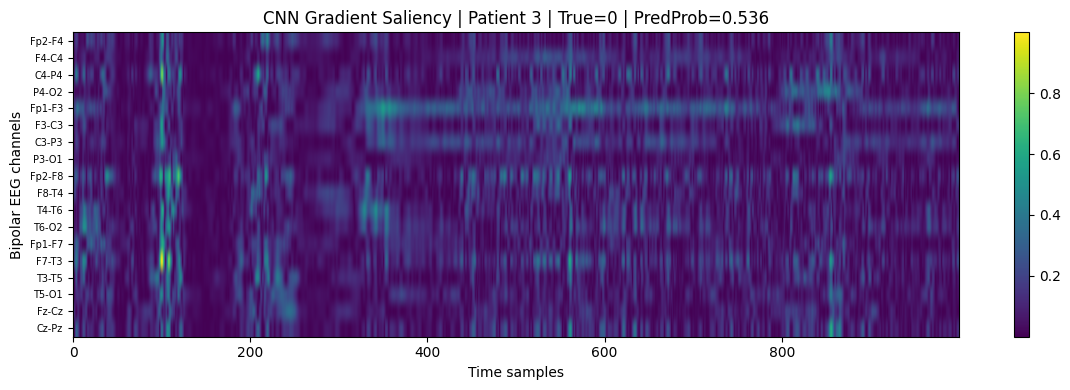

cnn {'saliency_fig': '/workspace/NeuroXAI/outputs/figures/realistic_cnn_saliency.png', 'patient_id': 3, 'true_label': 0, 'pred_label': 1, 'pred_prob': 0.535688579082489}
[DatasetNPY] windows=30785 patients=55
[DatasetNPY] windows=6062 patients=8
[DatasetNPY] windows=8589 patients=16
[Sampler] pos=6675 neg=24110 batches/epoch=481


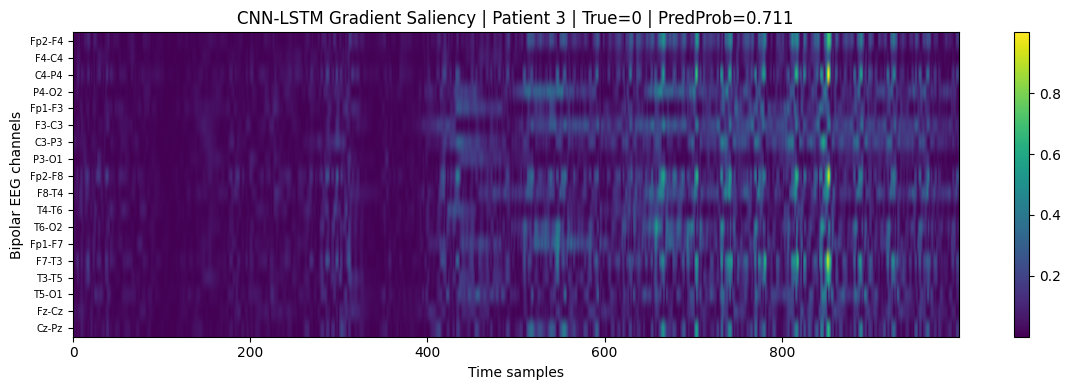

cnn_lstm {'saliency_fig': '/workspace/NeuroXAI/outputs/figures/realistic_cnn_lstm_saliency.png', 'patient_id': 3, 'true_label': 0, 'pred_label': 1, 'pred_prob': 0.7109895944595337}
[DatasetNPY] windows=30785 patients=55
[DatasetNPY] windows=6062 patients=8
[DatasetNPY] windows=8589 patients=16
[Sampler] pos=6675 neg=24110 batches/epoch=481


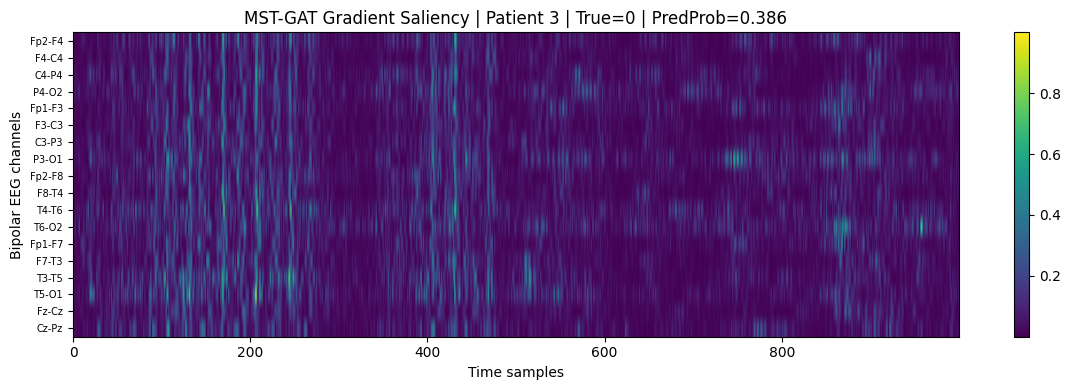

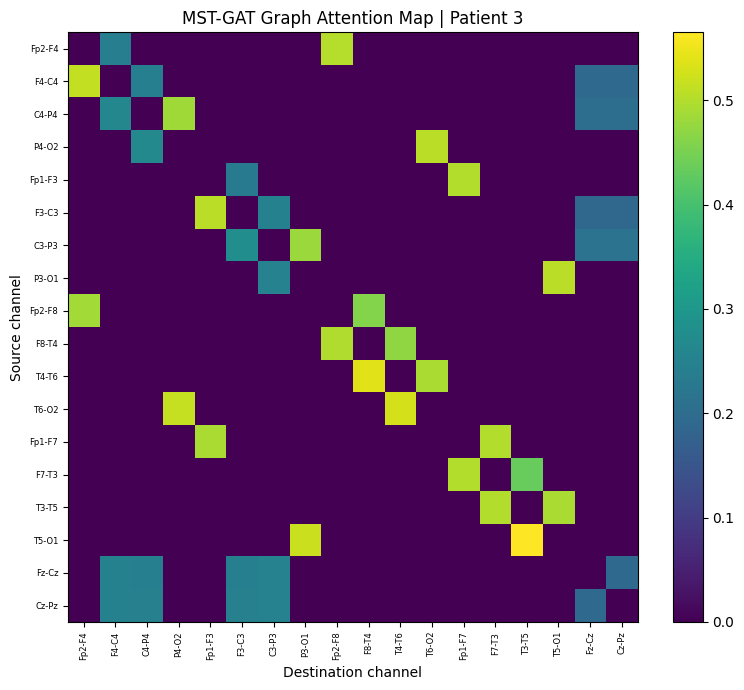

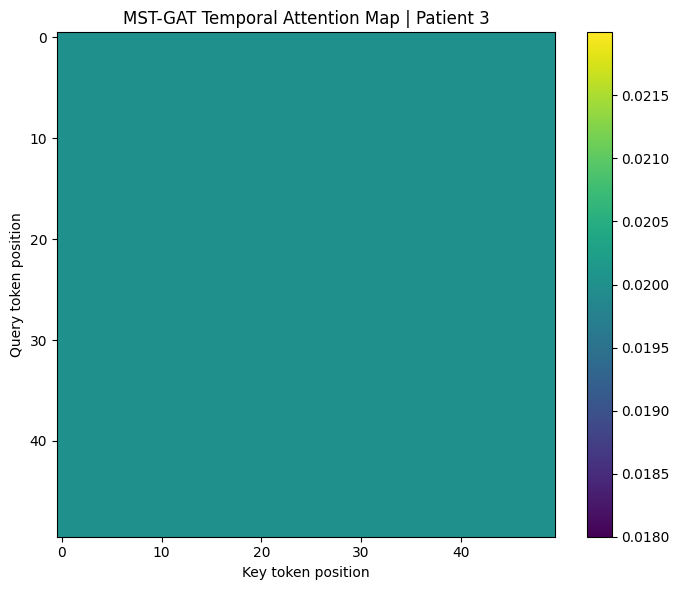

mst_gat {'saliency_fig': '/workspace/NeuroXAI/outputs/figures/realistic_mst_gat_saliency.png', 'graph_attention_fig': '/workspace/NeuroXAI/outputs/figures/realistic_mst_gat_graph_attention.png', 'temporal_attention_fig': '/workspace/NeuroXAI/outputs/figures/realistic_mst_gat_temporal_attention.png', 'patient_id': 3, 'true_label': 0, 'pred_label': 1, 'pred_prob': 0.3857245445251465}


In [23]:
# Run this after the comparison cell if you want saved explainability figures for each dev model.

def build_test_loader_only(test_ids):
    _, _, test_ds, _, _, test_loader = build_dataloaders(
        train_ids=train_ids,
        val_ids=val_ids,
        test_ids=test_ids,
        npy_dir=DATA_CACHE,
        meta=patient_meta,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        seed=42,
    )
    return test_loader

def load_best_model_from_result(result):
    model = build_model(result["model_name"])
    ckpt = torch.load(result["ckpt_path"], map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model

for r in comparison_results:
    test_loader = build_test_loader_only(r["test_ids"])
    model = load_best_model_from_result(r)
    out = explain_one_batch(
        model=model,
        test_loader=test_loader,
        threshold=r["threshold"],
        model_name=r["model_name"],
        save_prefix=f"{SPLIT_MODE}"
    )
    print(r["model_name"], out)